In [21]:
import torch
from sklearn.model_selection import train_test_split
import yaml
import argparse
import shutil
from collections import namedtuple
import os
import datetime


# Custom Libraries
from utils.data_generator import DataGenerator
from utils.agent import TrainModel
from utils.helper import to_python_native, gen_experiment_name, set_seed, save_model_state
from utils.pennylane.model import Qkernel

In [22]:
# === Backend Configuration ===
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

set_seed(42)
device

device(type='mps')

In [23]:
data_generator = DataGenerator(
        dataset_name= 'corners',
        file_path='data/corners.npy',
    )

training_data, training_labels, testing_data, testing_labels = data_generator.generate_dataset()
training_data = torch.tensor(training_data.to_numpy(), dtype=torch.float32, requires_grad=True)
testing_data = torch.tensor(testing_data.to_numpy(), dtype=torch.float32, requires_grad=True)
training_labels = torch.tensor(training_labels.to_numpy(), dtype=torch.int)
testing_labels = torch.tensor(testing_labels.to_numpy(), dtype=torch.int)

In [24]:
kernel = Qkernel(
        device='lightning.qubit',
        n_qubits=4,
        trainable=True,
        input_scaling=True,
        data_reuploading=True,
        ansatz='embedding_paper',
        ansatz_layers=5,
        noisy=False,
        noise_prob = 0.2,
        diff_method= 'adjoint'
    )

In [25]:
agent = TrainModel(
        kernel=kernel,
        training_data=training_data,
        training_labels=training_labels,
        testing_data=testing_data,
        testing_labels=testing_labels,
        optimizer='gd',
        lr= 0.1,
        mclr=0.01,
        cclr=0.01,
        epochs=100,
        train_method='ccka',
        target_accuracy=0.95,
        get_alignment_every=1000,
        validate_every_epoch=1,
        base_path='../',
        lambda_kao=0.001,
        lambda_co=0.001,
        clusters=2,
        use_kmeans=True
    )

Epochs:  10


In [26]:
def plot_ccka_state_2d(
    model,
    prev=None,                      # optional dict with keys: 'X', 'C', 'S' for BEFORE positions
    focus_class=None,               # e.g., 0 or 1; others are faded
    title="CCKA (2D): datapoints / centroids / sub-centroids + movement",
    max_point_arrows_per_class=5, # limit arrows per class for readability
    point_alpha=0.9, other_alpha=0.5, arrow_alpha=0.6,
    figsize=(8,7), seed=123, savepath=None
):
    """
    FIXED: uses cmap.colors (list) instead of cmap[i] to avoid 'ListedColormap is not subscriptable'.
    Expects:
      - model._training_data : (n,2) tensor
      - model._training_labels : (n,) tensor/np array
      - model._main_centroids : nn.ParameterList of length (#classes), each (2,)
      - model._class_centroids: nn.ParameterList of length (#classes * clusters), each (2,)
      - model._class_centroid_labels: list of tensors, one per class, each of shape (clusters,)
      - model._n_classes : tensor of unique class labels (order aligns with _main_centroids blocks)
    `prev` (optional): {'X': (n,2), 'C': (k,2), 'S': (m,2)} to draw BEFORE→NOW arrows.
    """
    import numpy as _np
    from matplotlib.lines import Line2D as _Line2D
    import matplotlib.pyplot as _plt

    rng = _np.random.default_rng(seed)

    # ---- pull current data from model (robust to torch/np) ----
    def _to_np(x):
        try:
            import torch as _torch
            if isinstance(x, _torch.Tensor):
                return x.detach().cpu().numpy()
        except Exception:
            pass
        return _np.asarray(x)

    X = _to_np(model._training_data); assert X.shape[1] == 2
    y = _to_np(model._training_labels).reshape(-1)

    # main centroids, ordered by model._n_classes
    C = _np.stack([_to_np(p) for p in model._main_centroids], axis=0) if len(model._main_centroids) else _np.empty((0,2))
    C_classes = _to_np(model._n_classes).reshape(-1) if hasattr(model, "_n_classes") and model._n_classes is not None else _np.unique(y)

    # sub-centroids & their class labels
    S = _np.stack([_to_np(p) for p in model._class_centroids], axis=0) if len(model._class_centroids) else _np.empty((0,2))
    if hasattr(model, "_class_centroid_labels") and model._class_centroid_labels:
        S_classes = _np.concatenate([_to_np(block).reshape(-1) for block in model._class_centroid_labels])
    else:
        S_classes = _np.array([], dtype=y.dtype)

    # all class ids present
    parts = [y, C_classes]
    if S_classes.size: parts.append(S_classes)
    classes = _np.unique(_np.concatenate(parts).ravel())

    # ---- color per class (use list of RGBA tuples) ----
    palette = list(_plt.get_cmap('tab20').colors)  # length 20
    color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(sorted(classes))}

    def _alpha(cls):
        return point_alpha if (focus_class is None or cls == focus_class) else other_alpha

    _plt.figure(figsize=figsize)

    # ---- datapoints & optional movement arrows ----
    for cls in classes:
        idx = _np.where(y == cls)[0]
        if idx.size == 0: 
            continue
        col = color_map[cls]; a = _alpha(cls)

        # base scatter
        _plt.scatter(X[idx,0], X[idx,1], s=16, c=[col], alpha=a, marker='o', edgecolors='none')

        # arrows (points) if prev given
        if prev is not None and 'X' in prev and prev['X'] is not None:
            Xprev = _np.asarray(prev['X'])
            use_idx = idx
            if isinstance(max_point_arrows_per_class, int) and idx.size > max_point_arrows_per_class:
                use_idx = rng.choice(idx, size=max_point_arrows_per_class, replace=False)
            dx = X[use_idx,0] - Xprev[use_idx,0]
            dy = X[use_idx,1] - Xprev[use_idx,1]
            _plt.quiver(
                Xprev[use_idx,0], Xprev[use_idx,1],
                dx, dy,
                angles='xy', scale_units='xy', scale=1.0,
                width=0.003, alpha=min(arrow_alpha, a), color=col
            )

    # ---- main centroids (✖) & optional arrows ----
    if C.size:
        for j, cls in enumerate(C_classes):
            col = color_map[cls]; a = _alpha(cls)
            _plt.scatter(C[j,0], C[j,1], s=140, marker='X', c=[col], alpha=a,
                        edgecolors='k', linewidths=0.7)
            if prev is not None and 'C' in prev and prev['C'] is not None:
                Cprev = _np.asarray(prev['C'])
                _plt.quiver(
                    Cprev[j,0], Cprev[j,1],
                    C[j,0]-Cprev[j,0], C[j,1]-Cprev[j,1],
                    angles='xy', scale_units='xy', scale=1.0,
                    width=0.005, alpha=min(arrow_alpha, a), color=col
                )

    # ---- sub-centroids (◆) & optional arrows ----
    if S.size and S_classes.size:
        for j, cls in enumerate(S_classes):
            col = color_map[cls]; a = _alpha(cls)
            _plt.scatter(S[j,0], S[j,1], s=80, marker='D', c=[col], alpha=a,
                        edgecolors='k', linewidths=0.5)
            if prev is not None and 'S' in prev and prev['S'] is not None:
                Sprev = _np.asarray(prev['S'])
                _plt.quiver(
                    Sprev[j,0], Sprev[j,1],
                    S[j,0]-Sprev[j,0], S[j,1]-Sprev[j,1],
                    angles='xy', scale_units='xy', scale=1.0,
                    width=0.004, alpha=min(arrow_alpha, a), color=col
                )

    # ---- legends ----
    class_handles = [_Line2D([0],[0], marker='o', linestyle='None', color=color_map[cls], label=str(cls)) for cls in sorted(classes)]
    cent_proxy   = _Line2D([0],[0], marker='X', linestyle='None', color='k', label='Centroid', markerfacecolor='w')
    subc_proxy   = _Line2D([0],[0], marker='D', linestyle='None', color='k', label='Sub-centroid', markerfacecolor='w')

    leg1 = _plt.legend(handles=class_handles, title="Classes", loc='upper right', frameon=True)
    _plt.gca().add_artist(leg1)
    _plt.legend(handles=[cent_proxy, subc_proxy], title="Markers", loc='lower right', frameon=True)

    _plt.title(title)
    _plt.axis('equal')
    _plt.grid(True, alpha=0.25)
    _plt.tight_layout()

    if savepath:
        _plt.savefig(savepath, dpi=180, bbox_inches='tight')
    _plt.show()


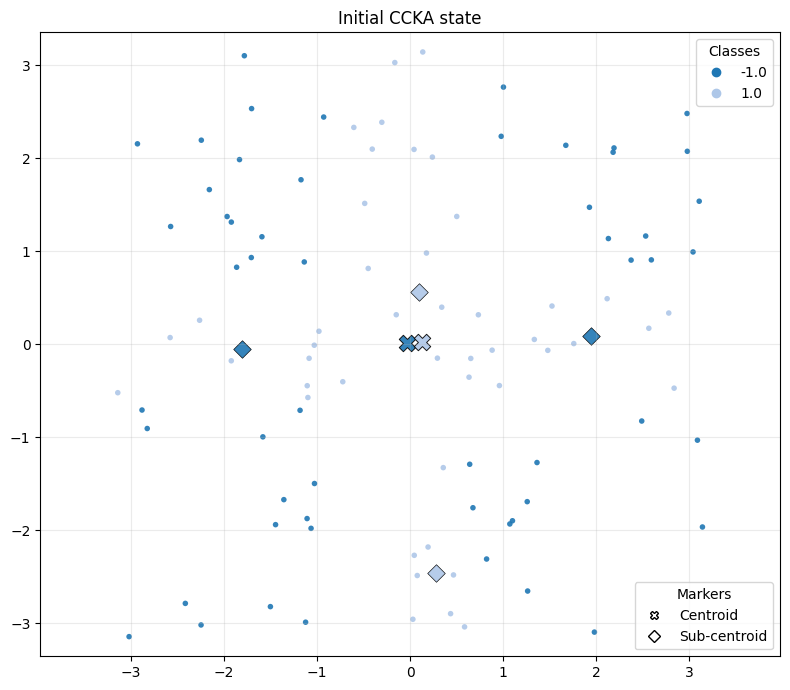

In [27]:
plot_ccka_state_2d(agent, title="Initial CCKA state")

In [28]:
agent.fit_kernel(training_data, training_labels)


Started Training


(Qkernel(),
 [Parameter containing:
  tensor([[0.7739, 1.0158, 0.8650, 1.0580],
          [0.9027, 1.1496, 1.0104, 0.9487],
          [0.9216, 1.0735, 0.7373, 0.8943],
          [1.2710, 0.9678, 0.5269, 0.7452],
          [0.8937, 0.9897, 0.5651, 1.1846]], requires_grad=True),
  Parameter containing:
  tensor([[ 2.1813,  2.6485, -0.8468,  2.7384],
          [-0.5589,  0.4531, -1.5809,  2.1655],
          [ 2.7428, -2.1105,  2.6324,  0.4275],
          [ 2.2568,  0.4111,  1.5877, -0.2886],
          [ 2.3738,  0.4552, -1.4376,  0.7849]], requires_grad=True),
  Parameter containing:
  tensor([[-1.4231, -0.3221, -1.2499,  2.0758],
          [-2.4677, -1.3539, -0.9201, -1.7901],
          [ 0.2724, -3.1511,  2.9004, -2.7629],
          [ 2.3850,  0.5395, -0.9773,  1.7542],
          [ 0.4799,  2.4880,  0.3366, -0.9712]], requires_grad=True)],
 ParameterList(
     (0): Parameter containing: [torch.float32 of size 2]
     (1): Parameter containing: [torch.float32 of size 2]
 ),
 ParameterLis

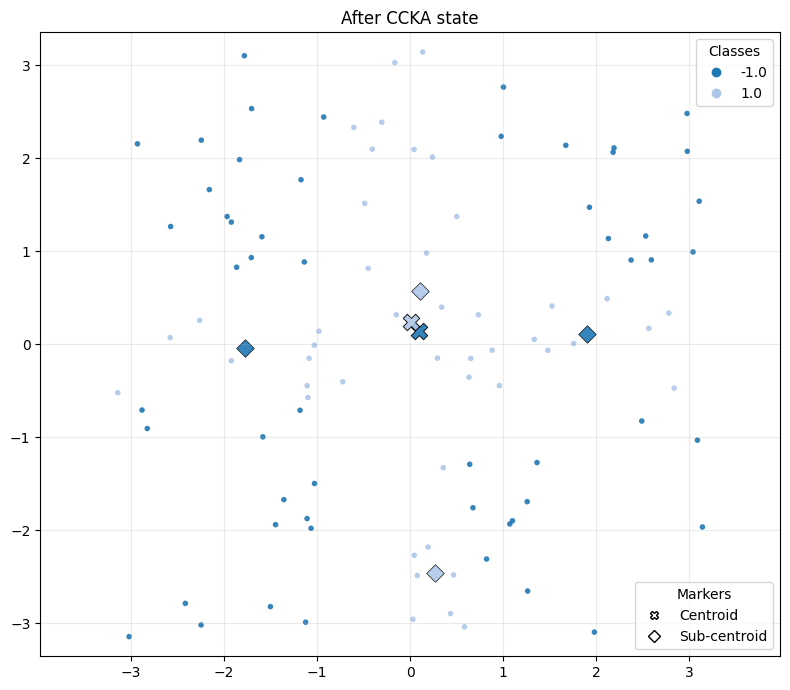

In [30]:
plot_ccka_state_2d(agent, title="After CCKA state")